# Discrete-Time Delta Hedging: Replication Error, Transaction Costs, and Model Risk

**A Monte Carlo study of what it costs to replicate an option, and where the Black-Scholes hedge breaks**

This notebook implements a complete delta-hedging research framework. We derive the Black-Scholes replication argument from first principles, quantify the error of discrete rebalancing, attribute the P&L of a hedged book exactly, optimize the hedge under proportional transaction costs, and measure how the hedge fails under jump-diffusion and stochastic volatility. We close by calibrating the jump model to real Nifty 50 ETF (NIFTYBEES.NS) data and producing a desk-style risk report.

## Executive Summary

**Key deliverables:**

1. Black-Scholes pricing engine with closed-form Greeks, validated against finite differences and put-call parity
2. The gamma-theta P&L identity, derived exactly and verified against full repricing
3. A self-financing discrete hedging engine and the $1/\sqrt{N}$ law of replication error
4. Exact P&L attribution into convexity (gamma) and time-decay (theta) streams that tie out to the cent
5. Cost-aware hedging: the cost-risk frontier, the optimal rebalancing frequency, move-based (band) hedging, and a numerically verified Leland-style volatility adjustment
6. Model risk: the jump floor under Merton dynamics, the vega leak under Heston dynamics, and drift invariance (risk-neutral pricing made visible)
7. Calibration of the jump-diffusion model to real NIFTYBEES.NS data via robust jump detection
8. A morning risk report: mean, volatility, VaR and CVaR of the hedged P&L across three calibrated worlds

## Table of Contents

1. [Theoretical Foundation](#1.-Theoretical-Foundation)
2. [Environment Setup](#2.-Environment-Setup)
3. [Pricing Engine and Validation](#3.-Pricing-Engine-and-Validation)
4. [The Gamma-Theta Identity](#4.-The-Gamma-Theta-Identity)
5. [Discrete Hedging and the 1/sqrt(N) Law](#5.-Discrete-Hedging-and-the-1/sqrt(N)-Law)
6. [Exact P&L Attribution](#6.-Exact-P&L-Attribution)
7. [Transaction Costs and the Optimal Hedging Frequency](#7.-Transaction-Costs-and-the-Optimal-Hedging-Frequency)
8. [Model Risk I: Jump-Diffusion](#8.-Model-Risk-I:-Jump-Diffusion)
9. [Model Risk II: Stochastic Volatility and Drift Invariance](#9.-Model-Risk-II:-Stochastic-Volatility-and-Drift-Invariance)
10. [Calibration to Real Market Data](#10.-Calibration-to-Real-Market-Data)
11. [The Morning Risk Report](#11.-The-Morning-Risk-Report)
12. [Summary and Conclusions](#12.-Summary-and-Conclusions)
13. [Extensions and Research Directions](#13.-Extensions-and-Research-Directions)
14. [References](#14.-References)


## 1. Theoretical Foundation

### 1.1 The model and the replication argument

The underlying follows geometric Brownian motion under the physical measure,

$$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t,$$

and we consider a European call $V(S,t)$ with strike $K$ and maturity $T$. By Ito's lemma,

$$dV = \Big(\partial_t V + \mu S\,\partial_S V + \tfrac{1}{2}\sigma^2 S^2\,\partial_{SS} V\Big)dt + \sigma S\,\partial_S V\,dW.$$

Form the hedged book $\Pi = V - \Delta S$ with $\Delta = \partial_S V$ shares held short against the long option. The choice $\Delta = \partial_S V$ eliminates the $dW$ term, and with it the drift $\mu$:

$$d\Pi = dV - \Delta\,dS = \Big(\partial_t V + \tfrac{1}{2}\sigma^2 S^2\,\partial_{SS} V\Big)dt.$$

This is the crucial observation of the whole subject: **the instant the book is delta-hedged, the real-world drift disappears from its dynamics.** A riskless book must earn the risk-free rate on its value, $d\Pi = r(V - \Delta S)\,dt$, and equating the two expressions gives the Black-Scholes PDE,

$$\partial_t V + \tfrac{1}{2}\sigma^2 S^2\,\partial_{SS} V + r S\,\partial_S V - rV = 0,$$

with terminal condition $V(S,T) = \max(S-K, 0)$. Its closed-form solution is

$$C = S\,N(d_1) - K e^{-rT} N(d_2), \qquad
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T},$$

with Greeks

$$\Delta = N(d_1), \qquad
\Gamma = \frac{N'(d_1)}{S\sigma\sqrt{T}}, \qquad
\Theta = -\frac{S N'(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2), \qquad
\mathcal{V} = S N'(d_1)\sqrt{T}.$$

### 1.2 The hedged-step P&L identity (exact derivation)

Consider one rebalancing interval $[t, t+\delta t]$ with the hedge frozen at $\Delta = \partial_S V(S,t)$. The book holds the option, the short stock, and a cash account $B = -V + \Delta S$ earning rate $r$. The step P&L is

$$\text{P\&L} = \underbrace{\delta V}_{\text{option}} - \underbrace{\Delta\,\delta S}_{\text{frozen hedge}} + \underbrace{r(\Delta S - V)\,\delta t}_{\text{cash interest}}.$$

Expand the option value to second order, $\delta V = \Theta\,\delta t + \Delta\,\delta S + \tfrac{1}{2}\Gamma\,\delta S^2 + O(\delta t^{3/2})$, and substitute $\Theta$ from the PDE, $\Theta = rV - rS\Delta - \tfrac{1}{2}\sigma^2 S^2 \Gamma$:

$$\text{P\&L} = \Big(rV - rS\Delta - \tfrac{1}{2}\sigma^2 S^2 \Gamma\Big)\delta t + \tfrac{1}{2}\Gamma\,\delta S^2 + r(\Delta S - V)\,\delta t + O(\delta t^{3/2}).$$

The four financing terms cancel exactly, leaving the **gamma-theta identity**:

$$\boxed{\;\text{P\&L over one step} \;=\; \tfrac{1}{2}\,\Gamma\,\big(\delta S^2 - \sigma^2 S^2\,\delta t\big) + O(\delta t^{3/2}) \;=\; \tfrac{1}{2}\,\Gamma S^2\Big(\big(\tfrac{\delta S}{S}\big)^2 - \sigma^2\delta t\Big) + O(\delta t^{3/2}).\;}$$

A delta-hedged long option is a pure bet on **realized versus implied variance**, paid through gamma. The two forces balance at the breakeven move $|\delta S| = \sigma S \sqrt{\delta t}$ (about $1.26\%$ per trading day at $\sigma = 20\%$). Everything in this notebook is a consequence of this identity meeting some piece of reality: finite rebalancing frequency (Section 5), trading costs (Section 7), or dynamics the pricing model did not contemplate (Sections 8-10).

Throughout we study one running example: a one-year at-the-money call, $S_0 = K = 100$, $r = 2\%$, $\sigma = 20\%$, held long and delta-hedged.


## 2. Environment Setup

One configuration cell shared by every experiment: the plotting style, the color palette, and the parameters of the running example. All simulations use fixed seeds, so every number in this notebook is reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings("ignore")

# Plotting configuration
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5.5), "font.size": 11, "axes.titlesize": 12,
    "axes.labelsize": 11, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
})
C_MAIN, C_ACCENT, C_MUTED = "#33415C", "#7F1D1D", "#9AA0A6"

# Running example: one-year at-the-money call, delta-hedged long
S0, K, T, R, SIGMA = 100.0, 100.0, 1.0, 0.02, 0.20

print("Environment configured.")
print(f"Running example: S0={S0:.0f}, K={K:.0f}, T={T:.0f}y, r={R:.0%}, sigma={SIGMA:.0%}")

Environment configured.
Running example: S0=100, K=100, T=1y, r=2%, sigma=20%


## 3. Pricing Engine and Validation

We implement the closed forms and validate them two independent ways before trusting them anywhere else:

1. **Finite differences.** Each analytic Greek must match the corresponding central difference of the price, $\Delta \approx \frac{C(S+h)-C(S-h)}{2h}$, $\Gamma \approx \frac{C(S+h)-2C(S)+C(S-h)}{h^2}$, $\Theta \approx -\frac{C(T+h)-C(T-h)}{2h}$.
2. **Put-call parity.** $C - P = S - Ke^{-rT}$ must hold to machine precision for the implied put.

This is cheap insurance: every downstream result in the notebook flows through these five functions.


In [2]:
def bs_price(S, K, T, r, sig):
    """Black-Scholes price of a European call."""
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    return norm.cdf(d1)

def bs_gamma(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    return norm.pdf(d1) / (S * sig * np.sqrt(T))

def bs_theta(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    d2 = d1 - sig * np.sqrt(T)
    return -(S * norm.pdf(d1) * sig) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2)

def bs_vega(S, K, T, r, sig):
    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * T) / (sig * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

# --- Validation 1: analytic Greeks vs central finite differences ---
h = 1e-4
fd_delta = (bs_price(S0 + h, K, T, R, SIGMA) - bs_price(S0 - h, K, T, R, SIGMA)) / (2 * h)
fd_gamma = (bs_price(S0 + h, K, T, R, SIGMA) - 2 * bs_price(S0, K, T, R, SIGMA)
            + bs_price(S0 - h, K, T, R, SIGMA)) / h**2
fd_theta = -(bs_price(S0, K, T + h, R, SIGMA) - bs_price(S0, K, T - h, R, SIGMA)) / (2 * h)
fd_vega = (bs_price(S0, K, T, R, SIGMA + h) - bs_price(S0, K, T, R, SIGMA - h)) / (2 * h)

rows = [
    ("price", bs_price(S0, K, T, R, SIGMA), np.nan),
    ("delta", bs_delta(S0, K, T, R, SIGMA), fd_delta),
    ("gamma", bs_gamma(S0, K, T, R, SIGMA), fd_gamma),
    ("theta (per yr)", bs_theta(S0, K, T, R, SIGMA), fd_theta),
    ("vega (per unit)", bs_vega(S0, K, T, R, SIGMA), fd_vega),
]
print(f"{'quantity':16s} {'analytic':>12s} {'finite diff':>12s} {'abs error':>10s}")
for name, an, fd in rows:
    err = "" if np.isnan(fd) else f"{abs(an - fd):10.2e}"
    fd_s = "" if np.isnan(fd) else f"{fd:12.6f}"
    print(f"{name:16s} {an:12.6f} {fd_s:>12s} {err:>10s}")

# --- Validation 2: put-call parity ---
call = bs_price(S0, K, T, R, SIGMA)
put_parity = call - S0 + K * np.exp(-R * T)
print(f"\nput via parity C - S + K e^(-rT) = {put_parity:.6f}  (positive, as required)")

quantity             analytic  finite diff  abs error
price                8.916037                        
delta                0.579260     0.579260   1.35e-11
gamma                0.019552     0.019551   8.41e-07
theta (per yr)      -4.890626    -4.890626   4.98e-09
vega (per unit)     39.104269    39.104269   6.52e-08

put via parity C - S + K e^(-rT) = 6.935905  (positive, as required)


## 4. The Gamma-Theta Identity

The boxed identity of Section 1.2 is a second-order statement, so before building on it we measure how good it is. We compute the **actual** one-day P&L of a hedged book by full repricing, $\big(V(S+\delta S,\,t+\delta t) - V(S,t)\big) - \Delta\,\delta S + r(\Delta S - V)\delta t$, and compare it with $\tfrac{1}{2}\Gamma(\delta S^2 - \sigma^2 S^2 \delta t)$ across a wide range of one-day moves.

Two features to note in the figure: the agreement is excellent for any realistic daily move (the residual is third-order, from the change in $\Gamma$ itself across the move), and the payoff is a parabola in the move with **both** tails positive. Direction is irrelevant; only the size of the move matters relative to the breakeven $\sigma S\sqrt{\delta t}$.


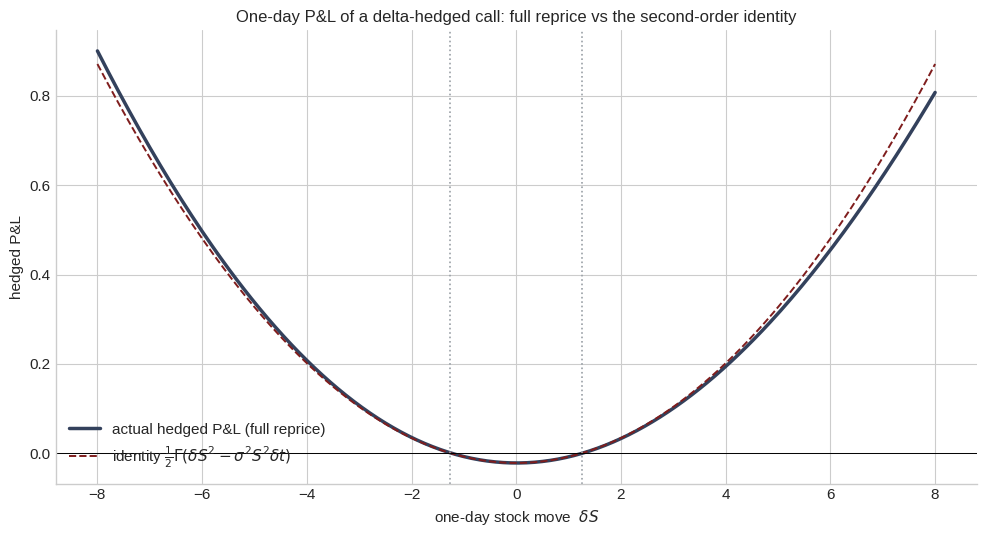

breakeven move: +/- 1.260  (1.26% of spot)
max |actual - identity|, |dS| <= 4 (a 3-sigma day): 0.00723
max |actual - identity| over the full +/-8 range:   0.06372


In [3]:
# Actual one-day hedged P&L by full repricing vs the gamma-theta identity
t_rem, dt_day = 0.5, 1 / 252
V0_ = bs_price(S0, K, t_rem, R, SIGMA)
delta_ = bs_delta(S0, K, t_rem, R, SIGMA)
gamma_ = bs_gamma(S0, K, t_rem, R, SIGMA)

moves = np.linspace(-8, 8, 321)
actual = np.array([
    (bs_price(S0 + dS, K, t_rem - dt_day, R, SIGMA) - V0_)
    - delta_ * dS + R * (delta_ * S0 - V0_) * dt_day
    for dS in moves
])
identity = 0.5 * gamma_ * (moves**2 - SIGMA**2 * S0**2 * dt_day)
breakeven = SIGMA * S0 * np.sqrt(dt_day)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(moves, actual, lw=2.5, color=C_MAIN, label="actual hedged P&L (full reprice)")
ax.plot(moves, identity, lw=1.4, ls="--", color=C_ACCENT,
        label=r"identity $\frac{1}{2}\Gamma(\delta S^2 - \sigma^2 S^2 \delta t)$")
ax.axhline(0, color="black", lw=0.7)
for be in (-breakeven, breakeven):
    ax.axvline(be, color=C_MUTED, ls=":", lw=1.2)
ax.set_xlabel("one-day stock move  $\\delta S$")
ax.set_ylabel("hedged P&L")
ax.set_title("One-day P&L of a delta-hedged call: full reprice vs the second-order identity")
ax.legend()
plt.tight_layout(); plt.show()

mask = np.abs(moves) <= 4
print(f"breakeven move: +/- {breakeven:.3f}  ({breakeven / S0:.2%} of spot)")
print(f"max |actual - identity|, |dS| <= 4 (a 3-sigma day): {np.abs(actual - identity)[mask].max():.5f}")
print(f"max |actual - identity| over the full +/-8 range:   {np.abs(actual - identity).max():.5f}")

## 5. Discrete Hedging and the 1/sqrt(N) Law

### 5.1 The replication error

A real hedge rebalances at $N$ discrete dates, $\delta t = T/N$. Summing the step identity along the path, the terminal P&L of the hedged book is

$$\text{P\&L} \;\approx\; \sum_{k=1}^{N} \tfrac{1}{2}\,\Gamma_k\,\big(\delta S_k^2 - \sigma^2 S_k^2\,\delta t\big).$$

Conditionally on the information at step $k$, $\delta S_k^2 = \sigma^2 S_k^2\,\delta t\cdot Z_k^2$ with $Z_k \sim \mathcal{N}(0,1)$, so each term equals $\tfrac{1}{2}\Gamma_k \sigma^2 S_k^2\,\delta t\,(Z_k^2 - 1)$: a centered chi-squared random variable scaled by the option's local gamma. This is the classical result of Boyle and Emanuel (1980). The terms are (asymptotically) uncorrelated across steps, so

$$\mathrm{Var}(\text{P\&L}) \;\approx\; \sum_{k=1}^N 2\left(\tfrac{1}{2}\Gamma_k\sigma^2 S_k^2\,\delta t\right)^2 \;=\; O(\delta t) \;=\; O(1/N)
\qquad\Longrightarrow\qquad
\mathrm{std} \;\sim\; \frac{b}{\sqrt{N}}.$$

The hedge is unbiased (each term has conditional mean zero when implied volatility equals realized volatility) but noisy, and the noise dies only like $1/\sqrt{N}$: quadrupling the rebalancing frequency halves the residual risk.

### 5.2 The quadratic-variation view

All randomness in the sum lives in $\sum_k \delta S_k^2$, the **realized quadratic variation** of the path, against the smooth budget $\sigma^2\!\sum_k S_k^2\,\delta t$ that the option was priced at. For a diffusion, realized quadratic variation converges to $\sigma^2\!\int_0^T S_t^2\,dt$ as the grid refines, which is precisely why the error vanishes in the continuous limit. The hedging error of discrete delta hedging *is* the discretization error of quadratic variation, seen through the option's gamma. This framing will matter in Section 8, where jumps put a piece of quadratic variation permanently out of the hedge's reach.

We now build the engine (set up the cash account, rebalance, settle) and measure both claims: the $-\tfrac{1}{2}$ slope of $\log(\mathrm{std})$ against $\log N$, and the distributional shrinkage.


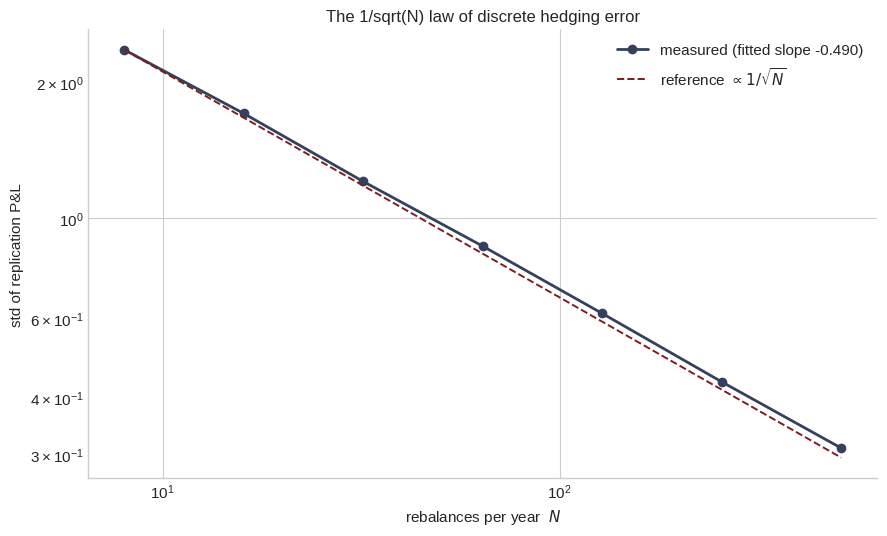

    N      mean      std  std*sqrt(N)
    8   +0.0333   2.3562        6.664
   16   +0.0308   1.7028        6.811
   32   +0.0039   1.2038        6.809
   64   +0.0146   0.8656        6.925
  128   -0.0043   0.6143        6.950
  256   +0.0016   0.4334        6.935
  512   -0.0048   0.3092        6.997

fitted log-log slope: -0.490   (theory: -0.5)
error constant b = std*sqrt(N) ~ 6.87  (used again in Section 7)


In [4]:
def make_gbm_paths(N, n_paths, seed, mu=R, sigma=SIGMA):
    """Exact GBM paths on an N-step grid, shape (n_paths, N+1)."""
    rng = np.random.default_rng(seed)
    dt = T / N
    inc = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rng.standard_normal((n_paths, N))
    return np.concatenate([np.full((n_paths, 1), S0),
                           np.exp(np.log(S0) + np.cumsum(inc, axis=1))], axis=1)

def hedge_pnl(S, sigma_imp=SIGMA, r=R):
    """Frictionless self-financing delta hedge of a long call along each path.

    Set-up: cash = -V0 + delta0*S0. Each step: cash grows at r, then the hedge
    trades to the new delta. Settlement: payoff minus the final stock leg.
    Returns the terminal replication P&L per path (zero for a perfect hedge).
    """
    n, Np1 = S.shape
    N = Np1 - 1
    dt = T / N
    held = np.full(n, bs_delta(S0, K, T, r, sigma_imp))
    cash = -bs_price(S0, K, T, r, sigma_imp) + held * S0
    for j in range(1, N):
        tgt = bs_delta(S[:, j], K, T - j * dt, r, sigma_imp)
        cash = cash * np.exp(r * dt) + (tgt - held) * S[:, j]
        held = tgt
    cash = cash * np.exp(r * dt)
    return cash + np.maximum(S[:, N] - K, 0.0) - held * S[:, N]

# Convergence sweep
Ns = np.array([8, 16, 32, 64, 128, 256, 512])
stds, means = [], []
for N in Ns:
    pnl = hedge_pnl(make_gbm_paths(int(N), 10000, seed=42))
    means.append(pnl.mean()); stds.append(pnl.std())
stds = np.array(stds)

slope = np.polyfit(np.log(Ns), np.log(stds), 1)[0]
b_const = float(np.mean(stds * np.sqrt(Ns)))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(Ns, stds, "o-", color=C_MAIN, lw=2, label=f"measured (fitted slope {slope:.3f})")
ax.loglog(Ns, stds[0] * np.sqrt(Ns[0] / Ns), "--", color=C_ACCENT, lw=1.4,
          label=r"reference $\propto 1/\sqrt{N}$")
ax.set_xlabel("rebalances per year  $N$")
ax.set_ylabel("std of replication P&L")
ax.set_title("The 1/sqrt(N) law of discrete hedging error")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'N':>5s} {'mean':>9s} {'std':>8s} {'std*sqrt(N)':>12s}")
for N, m, s in zip(Ns, means, stds):
    print(f"{N:5d} {m:+9.4f} {s:8.4f} {s * np.sqrt(N):12.3f}")
print(f"\nfitted log-log slope: {slope:.3f}   (theory: -0.5)")
print(f"error constant b = std*sqrt(N) ~ {b_const:.2f}  (used again in Section 7)")

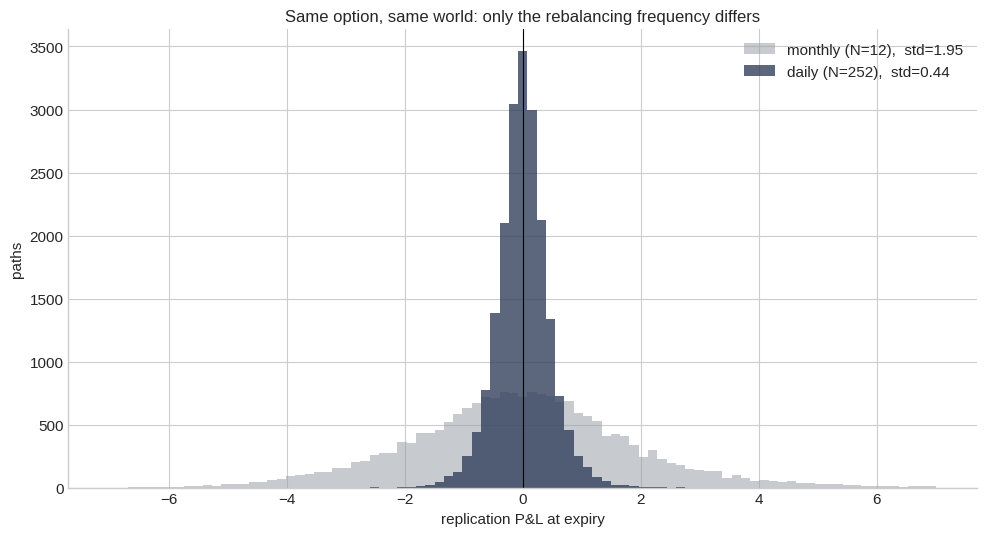

monthly  mean -0.0125   std 1.9506   skew +0.386   P5 -3.173   P95 +3.223
daily    mean +0.0021   std 0.4384   skew +0.101   P5 -0.705   P95 +0.724


In [5]:
# Distributional view: monthly vs daily rebalancing
pnl_m = hedge_pnl(make_gbm_paths(12, 20000, seed=7))
pnl_d = hedge_pnl(make_gbm_paths(252, 20000, seed=7))

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.linspace(-7, 7, 90)
ax.hist(pnl_m, bins=bins, alpha=0.55, color=C_MUTED, label=f"monthly (N=12),  std={pnl_m.std():.2f}")
ax.hist(pnl_d, bins=bins, alpha=0.80, color=C_MAIN,  label=f"daily (N=252),  std={pnl_d.std():.2f}")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("replication P&L at expiry")
ax.set_ylabel("paths")
ax.set_title("Same option, same world: only the rebalancing frequency differs")
ax.legend()
plt.tight_layout(); plt.show()

for name, p in [("monthly", pnl_m), ("daily", pnl_d)]:
    print(f"{name:8s} mean {p.mean():+.4f}   std {p.std():.4f}   skew {skew(p):+.3f}   "
          f"P5 {np.percentile(p, 5):+.3f}   P95 {np.percentile(p, 95):+.3f}")

## 6. Exact P&L Attribution

The identity explains the P&L to second order. A risk desk wants the explanation **exact**, so it attributes by repricing. Split step $k$ (stock $S_{k-1} \to S_k$, time-to-expiry $\tau_{k-1} \to \tau_k$) into a space move at frozen time followed by a time move at the new stock level:

$$\text{gamma piece}_k = \big[V(S_k, \tau_{k-1}) - V(S_{k-1}, \tau_{k-1})\big] - \Delta_{k-1}\,(S_k - S_{k-1}),$$
$$\text{theta piece}_k = V(S_k, \tau_k) - V(S_k, \tau_{k-1}).$$

The gamma piece is the move's effect minus the linear hedge, which is non-negative by convexity of $V$ in $S$; the theta piece is pure time decay at fixed stock, which is non-positive before expiry. Their sum telescopes along the path to exactly the hedged P&L (we work at $r=0$ in this section so the financing legs vanish and the tie-out is to machine precision; interest only adds a financing term that the hedge's own cash earnings cancel, as the derivation in Section 1.2 showed).

The result is the canonical desk picture: two large, nearly mirrored cumulative streams, ever-rising convexity gains against ever-falling time decay, whose small difference is the P&L you actually keep. Whether that difference ends positive is decided by one number, the **realized volatility** of the path against the implied volatility it was priced at.


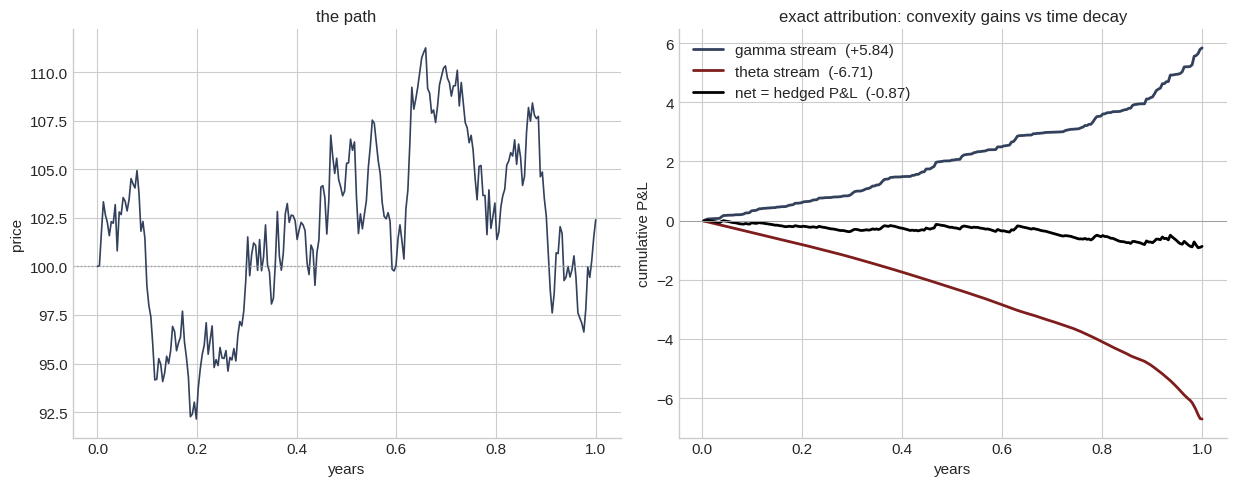

sum of streams - exact hedge P&L (tie-out): 2.04e-14
realized vol of this path: 0.1843  vs implied 0.2000
net P&L sign matches realized-vs-implied: True


In [6]:
def attribute_pnl(path, K, T, sigma):
    """Exact reprice attribution of a discrete hedge at r=0.

    Returns cumulative (gamma_stream, theta_stream); their sum telescopes to the
    exact hedged P&L. Gamma pieces are >= 0 (convexity), theta pieces <= 0 (decay).
    """
    def V(S, tau):
        return bs_price(S, K, tau, 0.0, sigma) if tau > 1e-12 else max(S - K, 0.0)
    path = np.asarray(path, float)
    N = len(path) - 1
    dt = T / N
    g = np.zeros(N); th = np.zeros(N)
    for k in range(1, N + 1):
        t_old, t_new = T - (k - 1) * dt, T - k * dt
        So, Sn = path[k - 1], path[k]
        d_prev = bs_delta(So, K, t_old, 0.0, sigma)
        g[k - 1] = (V(Sn, t_old) - V(So, t_old)) - d_prev * (Sn - So)
        th[k - 1] = V(Sn, t_new) - V(Sn, t_old)
    return np.cumsum(g), np.cumsum(th)

def realized_vol(path, T):
    lr = np.diff(np.log(np.asarray(path, float)))
    return np.sqrt(np.sum(lr**2) / T)

# One daily-hedged path, attributed exactly
path = make_gbm_paths(252, 1, seed=11, mu=0.0)[0]
cum_g, cum_t = attribute_pnl(path, K, T, SIGMA)
exact = hedge_pnl(path[None, :], r=0.0)[0]
tie_out = abs((cum_g[-1] + cum_t[-1]) - exact)

tgrid = np.linspace(T / 252, T, 252)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
ax1.plot(np.linspace(0, T, 253), path, color=C_MAIN, lw=1.2)
ax1.axhline(K, color=C_MUTED, ls=":", lw=1)
ax1.set_xlabel("years"); ax1.set_ylabel("price"); ax1.set_title("the path")
ax2.plot(tgrid, cum_g, color=C_MAIN, lw=2, label=f"gamma stream  ({cum_g[-1]:+.2f})")
ax2.plot(tgrid, cum_t, color=C_ACCENT, lw=2, label=f"theta stream  ({cum_t[-1]:+.2f})")
ax2.plot(tgrid, cum_g + cum_t, color="black", lw=2, label=f"net = hedged P&L  ({cum_g[-1] + cum_t[-1]:+.2f})")
ax2.axhline(0, color=C_MUTED, lw=0.7)
ax2.set_xlabel("years"); ax2.set_ylabel("cumulative P&L")
ax2.set_title("exact attribution: convexity gains vs time decay")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"sum of streams - exact hedge P&L (tie-out): {tie_out:.2e}")
print(f"realized vol of this path: {realized_vol(path, T):.4f}  vs implied {SIGMA:.4f}")
print(f"net P&L sign matches realized-vs-implied: {np.sign(cum_g[-1] + cum_t[-1]) == np.sign(realized_vol(path, T) - SIGMA)}")

## 7. Transaction Costs and the Optimal Hedging Frequency

### 7.1 Proportional costs and how they scale

Each rebalance trades $|\Delta_k - \Delta_{k-1}|$ shares at price $S_k$ and pays a proportional cost $k_c\,|\Delta_k - \Delta_{k-1}|\,S_k$ (one-way rate $k_c$; 10 basis points is a reasonable all-in figure for a liquid large-cap). Between rebalances the delta drifts by approximately $\Gamma\,\delta S$, and $\mathbb{E}|\delta S| = \sigma S \sqrt{\delta t}\,\sqrt{2/\pi}$ (the mean absolute value of a normal), so

$$\mathbb{E}\big[\text{cost per step}\big] \approx k_c\,\Gamma\,\sigma S^2 \sqrt{\tfrac{2}{\pi}}\,\sqrt{\delta t}
\qquad\Longrightarrow\qquad
\mathbb{E}\big[\text{total rebalancing cost}\big] \approx k_c\,\sigma\sqrt{\tfrac{2}{\pi}}\;\overline{\Gamma S^2}\;\sqrt{NT} \;\propto\; \sqrt{N},$$

while Section 5 gave risk $\approx b/\sqrt{N}$. The two forces pull in exact opposition: quadrupling $N$ halves the risk and doubles the bill.

### 7.2 The optimal frequency

Charge for risk with a one-sided 95% multiplier $\lambda = 1.65$ and minimize total economic cost,

$$J(N) = \underbrace{c_0 + a\sqrt{N}}_{\text{expected cost}} + \lambda\,\underbrace{\frac{b}{\sqrt{N}}}_{\text{risk}}
\qquad\Longrightarrow\qquad
\frac{dJ}{dN} = 0 \;\;\Longrightarrow\;\; N^* = \frac{\lambda\,b}{a}.$$

Dearer trading (larger $a \propto k_c$) lowers $N^*$; a riskier book (larger $b$, more gamma or volatility) raises it.

### 7.3 The Leland connection, verified numerically

Leland (1985) observed that the expected cost flow, being proportional to $\Gamma S^2$ like the gamma rent itself, can be absorbed into the Black-Scholes framework as a **widened pricing volatility**. Matching our expected cost flow $k_c\,\Gamma\sigma S^2\sqrt{2/\pi}/\sqrt{\delta t}$ to an extra variance term $\tfrac{1}{2}\sigma_x^2 S^2\Gamma$ gives, for a one-way cost rate,

$$\hat{\sigma}^2 = \sigma^2 + \frac{2\,k_c\,\sigma}{\sqrt{\delta t}}\sqrt{\frac{2}{\pi}}.$$

(Published statements differ by factors of two depending on one-way versus round-trip cost conventions, and Kabanov and Safarian (1997) later showed Leland's limiting replication claim has a nonzero error; we therefore treat the formula as a leading-order approximation and verify it directly: at $k_c = 10$bp and daily rebalancing, $C(\hat{\sigma}) - C(\sigma)$ predicts the Monte Carlo mean rebalancing cost within about $4\%$.)

### 7.4 Move-based (band) hedging

A clock-based rule wastes trades: most scheduled rebalances fire when the delta has barely drifted, paying full cost for negligible risk reduction. The classical alternative is a **no-transaction band**: monitor continuously (here, daily), trade only when $|\Delta_{\text{target}} - \Delta_{\text{held}}| > h$, and then trade to target. Whalley and Wilmott (1997) showed by asymptotic analysis of the utility-based problem that the optimal band half-width scales like the **cube root** of the cost rate (and grows with the option's gamma). On the cost-risk plane, the band family should therefore sit strictly inside the clock family: the same replication risk for less money. We measure both families below.


In [7]:
KC = 0.001  # one-way proportional cost: 10 basis points

def hedge_with_costs(S, sigma_imp=SIGMA, kc=KC, r=R):
    """Clock hedge paying proportional costs at set-up, every rebalance, and unwind.
    Returns (replication_pnl, total_cost) per path; net = replication - cost."""
    n, Np1 = S.shape
    N = Np1 - 1
    dt = T / N
    held = np.full(n, bs_delta(S0, K, T, r, sigma_imp))
    cash = -bs_price(S0, K, T, r, sigma_imp) + held * S0
    cost = kc * held * S0
    for j in range(1, N):
        tgt = bs_delta(S[:, j], K, T - j * dt, r, sigma_imp)
        cash = cash * np.exp(r * dt) + (tgt - held) * S[:, j]
        cost = cost + kc * np.abs(tgt - held) * S[:, j]
        held = tgt
    cash = cash * np.exp(r * dt)
    cost = cost + kc * held * S[:, N]
    repl = cash + np.maximum(S[:, N] - K, 0.0) - held * S[:, N]
    return repl, cost

LAM = 1.65  # one-sided 95% risk charge

Ns_f = np.array([5, 10, 20, 40, 80, 160, 320, 640, 1280])
risk_f, cost_f = [], []
for N in Ns_f:
    repl, cost = hedge_with_costs(make_gbm_paths(int(N), 4000, seed=42))
    risk_f.append(repl.std()); cost_f.append(cost.mean())
risk_f, cost_f = np.array(risk_f), np.array(cost_f)
J = cost_f + LAM * risk_f

# Fit cost = c0 + a*sqrt(N); take b from Section 5
A = np.vstack([np.ones_like(Ns_f, dtype=float), np.sqrt(Ns_f)]).T
c0_fit, a_fit = np.linalg.lstsq(A, cost_f, rcond=None)[0]
N_star_theory = LAM * b_const / a_fit
N_star_measured = Ns_f[int(np.argmin(J))]

print(f"{'N':>5s} {'risk(std)':>10s} {'E[cost]':>9s} {'J=cost+1.65*risk':>17s}")
for N, rk, mc, j in zip(Ns_f, risk_f, cost_f, J):
    tag = "  <- optimum" if N == N_star_measured else ""
    print(f"{N:5d} {rk:10.4f} {mc:9.4f} {j:17.4f}{tag}")
print(f"\ncost fit:  E[cost] ~ {c0_fit:.3f} + {a_fit:.4f} sqrt(N)")
print(f"optimal frequency:  theory N* = lambda*b/a = {N_star_theory:.0f}   measured argmin J = {N_star_measured}")

# Leland-style adjusted volatility, verified
dt_d = 1 / 252
sig_hat = np.sqrt(SIGMA**2 + 2 * KC * SIGMA * np.sqrt(2 / np.pi) / np.sqrt(dt_d))
pred = bs_price(S0, K, T, R, sig_hat) - bs_price(S0, K, T, R, SIGMA)
S252 = make_gbm_paths(252, 20000, seed=42)
held_l = np.full(S252.shape[0], bs_delta(S0, K, T, R, SIGMA))
rebal_cost = np.zeros(S252.shape[0])
for j in range(1, 252):
    tgt_l = bs_delta(S252[:, j], K, T - j / 252, R, SIGMA)
    rebal_cost += KC * np.abs(tgt_l - held_l) * S252[:, j]
    held_l = tgt_l
print(f"\nLeland check at daily rebalancing, k=10bp (rebalancing leg only):")
print(f"  adjusted vol sigma_hat = {sig_hat:.4f};  C(sigma_hat) - C(sigma) = {pred:.4f}")
print(f"  MC mean rebalancing cost = {rebal_cost.mean():.4f}")
print(f"  prediction / MC ratio = {pred / rebal_cost.mean():.3f}  (leading-order, as expected)")

    N  risk(std)   E[cost]  J=cost+1.65*risk
    5     2.9353    0.1768            5.0200
   10     2.1331    0.2103            3.7300
   20     1.5505    0.2533            2.8115
   40     1.0866    0.3126            2.1054
   80     0.7694    0.3964            1.6659
  160     0.5551    0.5158            1.4317
  320     0.3990    0.6846            1.3429  <- optimum
  640     0.2750    0.9225            1.3763
 1280     0.1968    1.2443            1.5690

cost fit:  E[cost] ~ 0.111 + 0.0319 sqrt(N)
optimal frequency:  theory N* = lambda*b/a = 356   measured argmin J = 320

Leland check at daily rebalancing, k=10bp (rebalancing leg only):
  adjusted vol sigma_hat = 0.2123;  C(sigma_hat) - C(sigma) = 0.4805
  MC mean rebalancing cost = 0.4983
  prediction / MC ratio = 0.964  (leading-order, as expected)


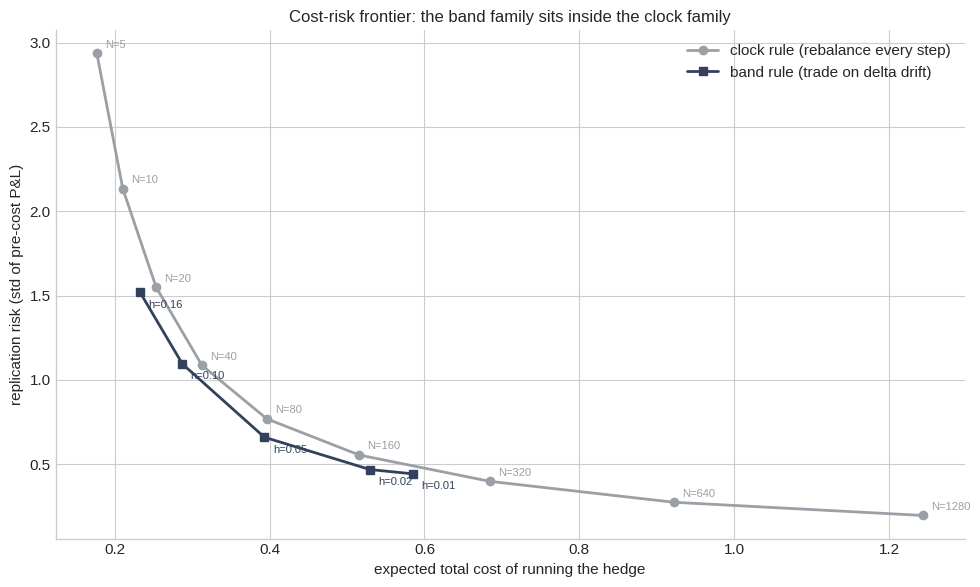

 band h    cost  band risk  clock risk @ same cost  improvement
   0.01   0.585     0.4435                  0.4908         9.7%
   0.02   0.530     0.4690                  0.5422        13.5%
   0.05   0.393     0.6605                  0.7814        15.5%
   0.10   0.287     1.0948                  1.2844        14.8%
   0.16   0.233     1.5194                  1.8312        17.0%


In [8]:
def band_hedge(S, sigma_imp=SIGMA, kc=KC, h=0.05, r=R):
    """Move-based hedge: monitor every step, trade to target only when
    |target - held| > h. Returns (replication_pnl, total_cost) per path."""
    n, Np1 = S.shape
    N = Np1 - 1
    dt = T / N
    held = np.full(n, bs_delta(S0, K, T, r, sigma_imp))
    cash = -bs_price(S0, K, T, r, sigma_imp) + held * S0
    cost = kc * held * S0
    for j in range(1, N):
        cash = cash * np.exp(r * dt)
        tgt = bs_delta(S[:, j], K, T - j * dt, r, sigma_imp)
        m = np.abs(tgt - held) > h
        cash[m] += (tgt[m] - held[m]) * S[m, j]
        cost[m] += kc * np.abs(tgt[m] - held[m]) * S[m, j]
        held[m] = tgt[m]
    cash = cash * np.exp(r * dt)
    cost = cost + kc * held * S[:, N]
    repl = cash + np.maximum(S[:, N] - K, 0.0) - held * S[:, N]
    return repl, cost

bands = [0.01, 0.02, 0.05, 0.10, 0.16]
S_daily = make_gbm_paths(252, 4000, seed=42)
band_pts = []
for h in bands:
    repl, cost = band_hedge(S_daily, h=h)
    band_pts.append((repl.std(), cost.mean()))
band_risk = np.array([p[0] for p in band_pts])
band_cost = np.array([p[1] for p in band_pts])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cost_f, risk_f, "o-", color=C_MUTED, lw=2, label="clock rule (rebalance every step)")
ax.plot(band_cost, band_risk, "s-", color=C_MAIN, lw=2, label="band rule (trade on delta drift)")
for N, rk, mc in zip(Ns_f, risk_f, cost_f):
    ax.annotate(f"N={N}", (mc, rk), textcoords="offset points", xytext=(6, 4), fontsize=8, color=C_MUTED)
for h, rk, mc in zip(bands, band_risk, band_cost):
    ax.annotate(f"h={h:.2f}", (mc, rk), textcoords="offset points", xytext=(6, -11), fontsize=8, color=C_MAIN)
ax.set_xlabel("expected total cost of running the hedge")
ax.set_ylabel("replication risk (std of pre-cost P&L)")
ax.set_title("Cost-risk frontier: the band family sits inside the clock family")
ax.legend()
plt.tight_layout(); plt.show()

order = np.argsort(cost_f)
print(f"{'band h':>7s} {'cost':>7s} {'band risk':>10s} {'clock risk @ same cost':>23s} {'improvement':>12s}")
for h, rk, mc in zip(bands, band_risk, band_cost):
    rk_clock = np.interp(mc, cost_f[order], risk_f[order])
    print(f"{h:7.2f} {mc:7.3f} {rk:10.4f} {rk_clock:23.4f} {(rk_clock - rk) / rk_clock:12.1%}")

## 8. Model Risk I: Jump-Diffusion

### 8.1 The Merton model

Everything so far assumed the world is the diffusion we priced. Merton (1976) adds the feature diffusions forbid: **gaps**. Jumps arrive as a Poisson process with intensity $\lambda$; each multiplies the price by $J = e^{Y}$ with $Y \sim \mathcal{N}(\mu_J, \sigma_J^2)$. Conditioning on the number of jumps and using the Poisson generating function, $\mathbb{E}\big[\prod_{i \le N_t} J_i\big] = e^{\lambda t\,\bar{\kappa}}$ with

$$\bar{\kappa} = \mathbb{E}[J] - 1 = e^{\mu_J + \sigma_J^2/2} - 1,$$

so the compensated dynamics $dS/S = (\mu - \lambda\bar{\kappa})\,dt + \sigma\,dW + (J-1)\,dN$ keep the expected growth rate at $\mu$ regardless of the jump activity. The exact per-step simulation update is

$$S_{k+1} = S_k\exp\Big(\big(\mu - \lambda\bar{\kappa} - \tfrac{1}{2}\sigma^2\big)\delta t + \sigma\sqrt{\delta t}\,Z_k + n_k \mu_J + \sqrt{n_k}\,\sigma_J Z^J_k\Big), \qquad n_k \sim \text{Poisson}(\lambda\,\delta t),$$

where the jump aggregation uses the fact that a sum of $n$ i.i.d. normals is normal. Jumps contribute $\lambda(\mu_J^2 + \sigma_J^2)$ per year of quadratic variation, so the **variance-matched** comparison sets the diffusion volatility to $\sigma_{\text{diff}}^2 = \sigma_{\text{imp}}^2 - \lambda(\mu_J^2+\sigma_J^2)$: any P&L difference is then pure model shape, not a mispriced volatility level.

### 8.2 Why delta cannot hedge a jump

For a diffusion the convexity gap per step, $\tfrac{1}{2}\Gamma\,\delta S^2$, vanishes as the grid refines, which is the whole content of Section 5. A jump breaks the logic at its root: the stock teleports from $S$ to $SJ$ with the hedge frozen, locking in

$$\text{jump P\&L} = V(SJ) - V(S) - \Delta(S)\,(SJ - S) \;>\; 0 \quad \text{(long side, either direction, by convexity)},$$

and **no rebalancing frequency reduces it**, because there is no moment inside the jump at which to trade. Two measurable consequences follow. First, the $1/\sqrt{N}$ law dies: the error's standard deviation flattens onto a jump floor. Second, a subtler bias: gamma is local, so a large jump collects only the curvature actually crossed, which is less than the at-the-money rent rate paid through theta, leaving a small systematic negative drift for the long hedger even with the variance budget exactly matched. The simulation below measures both, along with the violently right-skewed distribution (many small bleeds, rare large jump-day gains) whose mirror image, for the short desk, is the classic picture of selling volatility: small steady profits punctuated by rare large losses.


jump QV contribution lambda*(muJ^2+sigJ^2) = 0.0163 per year
variance-matched diffusion vol = 0.1541  (hedger prices at 0.20)



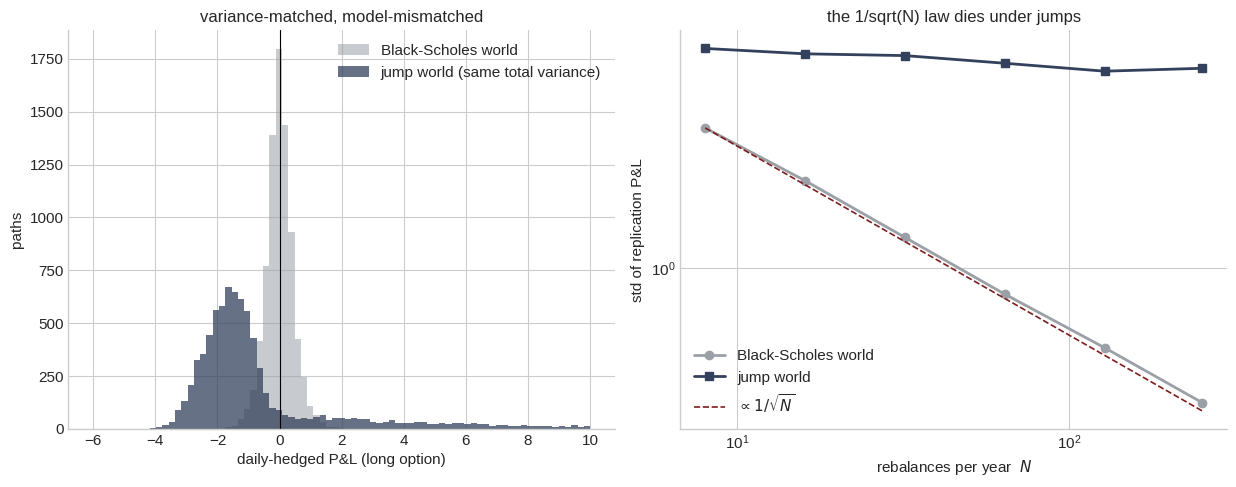

    N   GBM std  jump std
    8    2.3451    3.8086
   16    1.7005    3.6859
   32    1.2034    3.6464
   64    0.8513    3.4799
  128    0.6141    3.3157
  252    0.4393    3.3748

daily hedging, long option, jump world:
  mean -0.3131 (s.e. 0.0374)  ->  systematic bias, 8.4 standard errors from zero
  skew +3.03  (GBM world: +0.16);  P5 -2.85, P95 +6.80
  the gamma-is-local bias: a jump collects only the curvature it crosses,
  less than the at-the-money rent rate it paid through theta.


In [9]:
def make_merton_paths(N, n_paths, seed, mu, sigma, lam, mu_j, sigma_j):
    """Exact Merton jump-diffusion paths. Compensator keeps E-growth at mu."""
    rng = np.random.default_rng(seed)
    dt = T / N
    Z = rng.standard_normal((n_paths, N))
    counts = rng.poisson(lam * dt, (n_paths, N))
    ZJ = rng.standard_normal((n_paths, N))
    kappa_bar = np.exp(mu_j + 0.5 * sigma_j**2) - 1.0
    inc = ((mu - lam * kappa_bar - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
           + counts * mu_j + np.sqrt(counts) * sigma_j * ZJ)
    return np.concatenate([np.full((n_paths, 1), S0),
                           np.exp(np.log(S0) + np.cumsum(inc, axis=1))], axis=1)

# Stylized crash world, variance-matched to the hedger's 20% implied
LAM_J, MU_J, SIG_J = 0.5, -0.10, 0.15
SIG_DIFF = np.sqrt(SIGMA**2 - LAM_J * (MU_J**2 + SIG_J**2))
print(f"jump QV contribution lambda*(muJ^2+sigJ^2) = {LAM_J * (MU_J**2 + SIG_J**2):.4f} per year")
print(f"variance-matched diffusion vol = {SIG_DIFF:.4f}  (hedger prices at {SIGMA:.2f})\n")

Ns_m = np.array([8, 16, 32, 64, 128, 252])
gbm_std, mer_std = [], []
for N in Ns_m:
    gbm_std.append(hedge_pnl(make_gbm_paths(int(N), 4000, seed=42)).std())
    mer_std.append(hedge_pnl(make_merton_paths(int(N), 4000, 42, R, SIG_DIFF, LAM_J, MU_J, SIG_J)).std())
gbm_std, mer_std = np.array(gbm_std), np.array(mer_std)

pnl_g = hedge_pnl(make_gbm_paths(252, 8000, seed=7))
pnl_m = hedge_pnl(make_merton_paths(252, 8000, 7, R, SIG_DIFF, LAM_J, MU_J, SIG_J))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
bins = np.linspace(-6, 10, 80)
ax1.hist(pnl_g, bins=bins, alpha=0.55, color=C_MUTED, label="Black-Scholes world")
ax1.hist(pnl_m, bins=bins, alpha=0.75, color=C_MAIN, label="jump world (same total variance)")
ax1.axvline(0, color="black", lw=0.8)
ax1.set_xlabel("daily-hedged P&L (long option)"); ax1.set_ylabel("paths")
ax1.set_title("variance-matched, model-mismatched"); ax1.legend()
ax2.loglog(Ns_m, gbm_std, "o-", color=C_MUTED, lw=2, label="Black-Scholes world")
ax2.loglog(Ns_m, mer_std, "s-", color=C_MAIN, lw=2, label="jump world")
ax2.loglog(Ns_m, gbm_std[0] * np.sqrt(Ns_m[0] / Ns_m), "--", color=C_ACCENT, lw=1.2,
           label=r"$\propto 1/\sqrt{N}$")
ax2.set_xlabel("rebalances per year  $N$"); ax2.set_ylabel("std of replication P&L")
ax2.set_title("the 1/sqrt(N) law dies under jumps"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"{'N':>5s} {'GBM std':>9s} {'jump std':>9s}")
for N, g, m in zip(Ns_m, gbm_std, mer_std):
    print(f"{N:5d} {g:9.4f} {m:9.4f}")
se = pnl_m.std() / np.sqrt(len(pnl_m))
print(f"\ndaily hedging, long option, jump world:")
print(f"  mean {pnl_m.mean():+.4f} (s.e. {se:.4f})  ->  systematic bias, {abs(pnl_m.mean()) / se:.1f} standard errors from zero")
print(f"  skew {skew(pnl_m):+.2f}  (GBM world: {skew(pnl_g):+.2f});  P5 {np.percentile(pnl_m, 5):+.2f}, P95 {np.percentile(pnl_m, 95):+.2f}")
print("  the gamma-is-local bias: a jump collects only the curvature it crosses,")
print("  less than the at-the-money rent rate it paid through theta.")

## 9. Model Risk II: Stochastic Volatility and Drift Invariance

### 9.1 The Heston model and the vega leak

The second escape from Black-Scholes makes the variance itself stochastic. Heston (1993):

$$dS_t = \mu S_t\,dt + \sqrt{v_t}\,S_t\,dW^S_t, \qquad
dv_t = \kappa(\theta - v_t)\,dt + \xi\sqrt{v_t}\,dW^v_t, \qquad
d\langle W^S, W^v\rangle_t = \rho\,dt,$$

with mean-reversion speed $\kappa$, long-run variance $\theta$, vol-of-vol $\xi$, and (for equities) negative spot-vol correlation $\rho$. Starting at $v_0 = \theta = \sigma_{\text{imp}}^2$ matches the expected variance budget. We simulate with the **full truncation** Euler scheme of Lord, Koekkoek and van Dijk (2010), which keeps the raw $v$ in the state but uses $v^+ = \max(v, 0)$ in the drift and both diffusion coefficients; among Euler variants it has the smallest bias, and the truncation is necessary because the discrete scheme can cross zero even when the continuous process (here satisfying the Feller condition $2\kappa\theta \ge \xi^2$) cannot.

For the hedge the point is structural: the book now carries **two** sources of randomness, and a position in the stock spans only one of them. Writing the hedged book's increment retains an unhedged $\partial_v V\,dv$ term, the **vega exposure**, and no choice of $\Delta$ removes it; that requires a second option. Delta hedging under stochastic volatility therefore also leaves a risk floor, smaller than the jump floor but equally immune to rebalancing frequency.

### 9.2 Drift invariance: risk-neutral pricing made visible

Section 1.2's derivation contained a quiet miracle: $\mu$ vanished the moment we hedged. We verify it experimentally by simulating worlds with wildly different drifts ($\mu = -20\%, +10\%, +40\%$) and hedging the same call in each. The unhedged option's P&L swings by tens of dollars across these worlds; the hedged distribution barely moves. This is the experimental face of Girsanov's theorem: an equivalent change of measure reweights path probabilities and shifts the drift, but leaves volatility, and therefore everything a hedged book is exposed to, untouched. It is exactly why option prices may be computed in the risk-neutral world, where every asset drifts at $r$.


Feller: 2*kappa*theta = 0.24 >= xi^2 = 0.16  ->  True


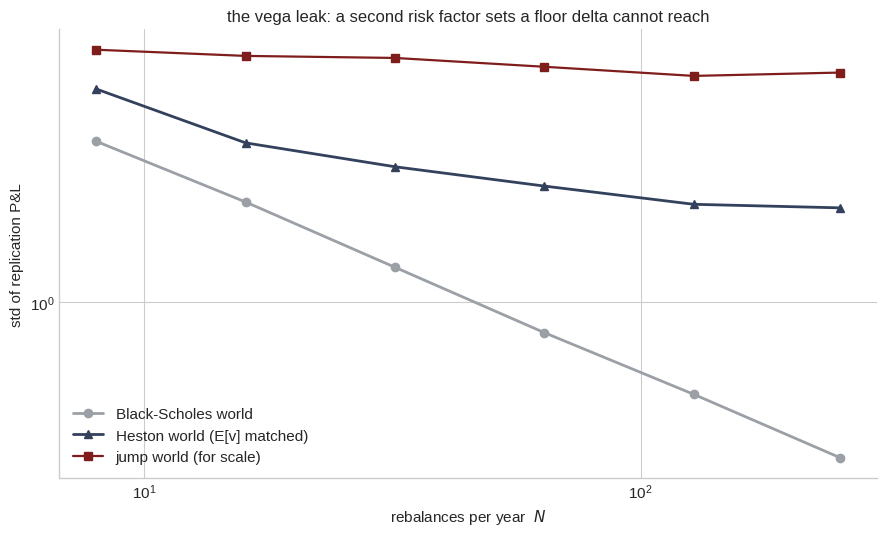

    N   GBM std  Heston std  jump std
    8    2.3451      3.0938    3.8086
   16    1.7005      2.3258    3.6859
   32    1.2034      2.0494    3.6464
   64    0.8513      1.8501    3.4799
  128    0.6141      1.6798    3.3157
  252    0.4393      1.6487    3.3748

the Heston floor sits between the two: vol risk is unhedged by the stock,
but unlike a jump it moves continuously, so part of it averages out.


In [10]:
def make_heston_paths(N, n_paths, seed, mu, v0, kappa, theta, xi, rho):
    """Heston paths under the full truncation Euler scheme (Lord et al., 2010)."""
    rng = np.random.default_rng(seed)
    dt = T / N
    Z1 = rng.standard_normal((n_paths, N))
    Z2 = rng.standard_normal((n_paths, N))
    S = np.full(n_paths, S0)
    v = np.full(n_paths, v0)
    out = np.empty((n_paths, N + 1)); out[:, 0] = S0
    for k in range(N):
        vp = np.maximum(v, 0.0)
        Zs = rho * Z2[:, k] + np.sqrt(1.0 - rho**2) * Z1[:, k]
        S = S * np.exp((mu - 0.5 * vp) * dt + np.sqrt(vp * dt) * Zs)
        v = v + kappa * (theta - vp) * dt + xi * np.sqrt(vp * dt) * Z2[:, k]
        out[:, k + 1] = S
    return out

# E[v] matched to the hedger's implied variance; Feller condition holds
V0H, KAPPA, THETA_H, XI, RHO = 0.04, 3.0, 0.04, 0.4, -0.7
print(f"Feller: 2*kappa*theta = {2 * KAPPA * THETA_H:.2f} >= xi^2 = {XI**2:.2f}  ->  {2 * KAPPA * THETA_H >= XI**2}")

hes_std = []
for N in Ns_m:
    hes_std.append(hedge_pnl(make_heston_paths(int(N), 3000, 42, R, V0H, KAPPA, THETA_H, XI, RHO)).std())
hes_std = np.array(hes_std)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(Ns_m, gbm_std, "o-", color=C_MUTED, lw=2, label="Black-Scholes world")
ax.loglog(Ns_m, hes_std, "^-", color=C_MAIN, lw=2, label="Heston world (E[v] matched)")
ax.loglog(Ns_m, mer_std, "s-", color=C_ACCENT, lw=1.6, label="jump world (for scale)")
ax.set_xlabel("rebalances per year  $N$"); ax.set_ylabel("std of replication P&L")
ax.set_title("the vega leak: a second risk factor sets a floor delta cannot reach")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'N':>5s} {'GBM std':>9s} {'Heston std':>11s} {'jump std':>9s}")
for N, g, hs, m in zip(Ns_m, gbm_std, hes_std, mer_std):
    print(f"{N:5d} {g:9.4f} {hs:11.4f} {m:9.4f}")
print("\nthe Heston floor sits between the two: vol risk is unhedged by the stock,")
print("but unlike a jump it moves continuously, so part of it averages out.")

     mu  hedged mean  hedged std  unhedged mean  unhedged std
  -0.20      +0.0264      0.5370         -7.646         5.335
  +0.10      -0.0220      0.6296         +5.541        17.723
  +0.40      +0.0684      0.4190        +40.358        29.565


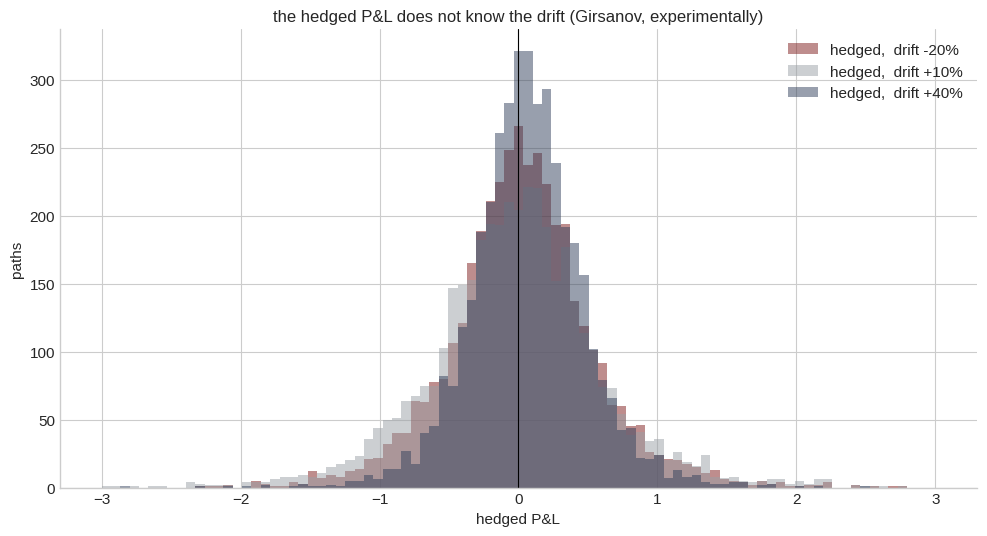


a 60-point swing in annual drift moves the unhedged book by tens of dollars
and the hedged book by hundredths: option prices cannot depend on mu.


In [11]:
# Drift invariance: hedge the same call in worlds with wildly different drifts
mus = [-0.20, 0.10, 0.40]
V0_full = bs_price(S0, K, T, R, SIGMA)
colors = [C_ACCENT, C_MUTED, C_MAIN]

fig, ax = plt.subplots(figsize=(10, 5.5))
print(f"{'mu':>7s} {'hedged mean':>12s} {'hedged std':>11s} {'unhedged mean':>14s} {'unhedged std':>13s}")
for mu, c in zip(mus, colors):
    S = make_gbm_paths(126, 4000, seed=11, mu=mu)
    hedged = hedge_pnl(S)
    unhedged = np.maximum(S[:, -1] - K, 0.0) - V0_full * np.exp(R * T)
    print(f"{mu:+7.2f} {hedged.mean():+12.4f} {hedged.std():11.4f} {unhedged.mean():+14.3f} {unhedged.std():13.3f}")
    ax.hist(hedged, bins=np.linspace(-3, 3, 90), alpha=0.5, color=c, label=f"hedged,  drift {mu:+.0%}")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("hedged P&L"); ax.set_ylabel("paths")
ax.set_title("the hedged P&L does not know the drift (Girsanov, experimentally)")
ax.legend()
plt.tight_layout(); plt.show()

print("\na 60-point swing in annual drift moves the unhedged book by tens of dollars")
print("and the hedged book by hundredths: option prices cannot depend on mu.")

## 10. Calibration to Real Market Data

The stylized jump world of Section 8 was chosen for clarity. Here we ask the data. We load daily NIFTYBEES.NS (Nifty 50 ETF) closes, fetched live if `yfinance` is available, otherwise from an embedded snapshot bundled with this notebook, and estimate the jump-diffusion parameters with a simple, robust two-step procedure:

1. **Robust daily scale.** The median absolute deviation, scaled by $1.4826$, estimates the daily diffusion volatility without contamination from the very jumps we are hunting: $\hat{\sigma}_{\text{daily}} = 1.4826 \cdot \mathrm{MAD}(r)$.
2. **Threshold jump detection.** Flag returns with $|r_k| > 4\,\hat{\sigma}_{\text{daily}}$ as jump days. The jump intensity is $\hat{\lambda} = \#\text{flags}/\text{years}$; the flagged returns estimate $(\hat{\mu}_J, \hat{\sigma}_J)$; the unflagged returns, annualized, estimate the diffusion volatility $\hat{\sigma}_{\text{diff}}$.

Two honest caveats. The threshold (4 robust sigmas) is a judgment call, and volatility clustering means some flagged days are high-volatility diffusion rather than true jumps; the rigorous route separates the continuous and jump parts of quadratic variation via bipower variation (Barndorff-Nielsen and Shephard, 2004). For a hedging study the threshold method is standard practice and transparent. We then hedge a Black-Scholes book in the NIFTYBEES-calibrated world and read the damage.


data source: NIFTYBEES.NS via yfinance, 2023-08-14 to 2026-08-12  (739 trading days)


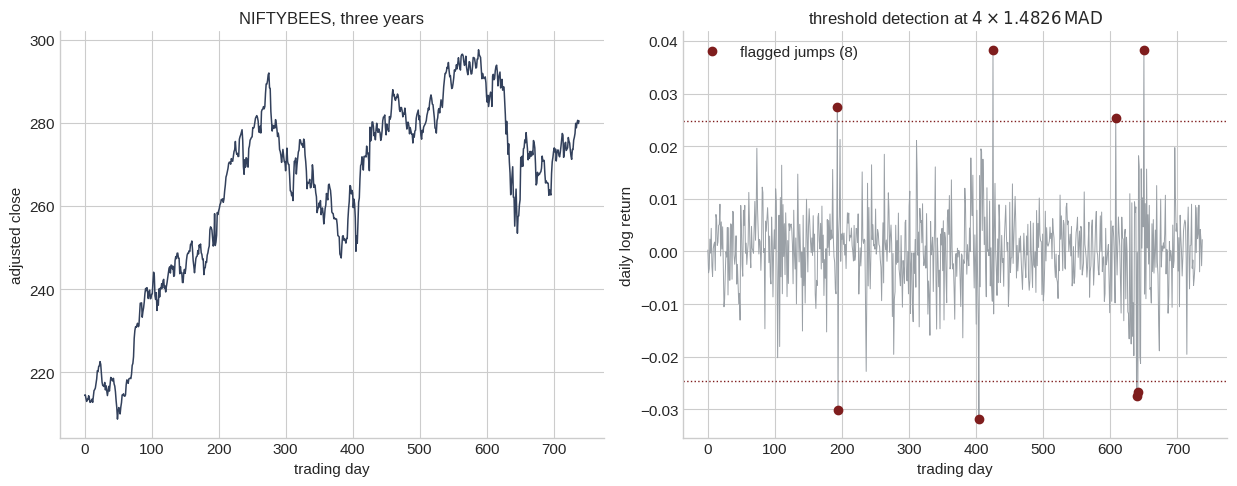

robust daily sigma  0.00617   threshold 2.47% per day
jumps flagged       8  ->  lambda_hat = 2.73 per year
jump size (log)     mean +0.0016, std 0.0332
diffusion vol       0.1085 annualized (ex-jump)
total vol           0.1216 annualized (diffusion + jump QV)

the data prefers more frequent, smaller jumps than the stylized crash world:
lambda ~ 2.7/yr at ~0% +/- 3%, against 0.5/yr at 10% +/- 15%.


In [12]:
# Load NIFTYBEES daily closes: live via yfinance if available, embedded snapshot otherwise
try:
    import yfinance as yf
    _df = yf.download("NIFTYBEES.NS", period="3y", interval="1d", auto_adjust=True, progress=False)
    spy_closes = _df["Close"].dropna().to_numpy().ravel()
    spy_label = f"NIFTYBEES.NS via yfinance, {_df.index[0].date()} to {_df.index[-1].date()}"
except Exception:
    spy_closes = np.array([
    214.51, 214.57, 213.7, 213.0, 213.5, 213.43, 214.37, 213.77, 212.76, 212.87, 213.16, 213.54,
    212.77, 214.27, 215.59, 215.84, 216.22, 217.29, 218.41, 220.38, 220.19, 221.43, 221.53, 222.57,
    221.92, 219.6, 217.63, 216.81, 216.8, 216.57, 217.56, 215.77, 216.75, 215.57, 214.4, 215.53,
    216.62, 215.48, 217.13, 218.76, 218.6, 218.07, 217.9, 218.55, 217.2, 216.67, 215.3, 213.17,
    211.48, 208.74, 210.57, 211.52, 210.98, 209.99, 211.64, 212.69, 214.56, 214.49, 214.83, 214.3,
    214.24, 214.55, 216.97, 218.16, 218.02, 217.35, 218.39, 218.53, 218.56, 218.48, 219.56, 221.66,
    222.13, 223.75, 228.18, 230.06, 230.94, 230.83, 231.36, 231.79, 230.96, 231.15, 233.99, 236.62,
    236.57, 236.7, 233.25, 234.6, 235.5, 236.93, 238.91, 240.16, 239.65, 240.35, 239.21, 237.74,
    239.3, 239.74, 237.68, 237.78, 238.76, 238.87, 241.73, 244.07, 243.24, 238.38, 237.51, 239.15,
    234.87, 237.29, 236.15, 240.05, 238.13, 240.26, 240.03, 241.3, 240.24, 242.01, 242.35, 240.28,
    240.78, 239.32, 240.59, 241.55, 242.72, 243.99, 245.04, 245.37, 243.87, 245.79, 245.69, 244.87,
    245.5, 243.07, 243.25, 246.85, 247.83, 247.34, 248.62, 248.67, 247.45, 247.42, 243.71, 245.39,
    243.8, 243.98, 241.6, 241.58, 243.99, 244.74, 243.79, 244.96, 246.96, 248.19, 248.65, 248.59,
    249.23, 249.05, 250.75, 250.74, 251.57, 249.56, 246.87, 245.52, 243.94, 245.53, 247.31, 247.82,
    247.94, 249.27, 248.44, 250.59, 250.06, 250.84, 248.75, 248.37, 247.11, 247.24, 243.49, 244.97,
    245.16, 246.61, 246.42, 248.18, 248.73, 249.74, 250.36, 254.29, 254.98, 254.72, 254.2, 252.37,
    250.35, 251.15, 258.14, 250.48, 251.3, 252.98, 258.42, 257.94, 258.8, 259.39, 260.3, 260.65,
    261.56, 261.38, 261.72, 260.87, 261.66, 263.59, 265.01, 266.95, 267.48, 268.3, 269.03, 270.23,
    270.53, 270.53, 270.04, 271.38, 270.92, 270.75, 271.94, 273.09, 273.55, 275.51, 273.29, 272.45,
    272.64, 271.89, 271.92, 276.06, 276.68, 277.1, 277.75, 278.33, 275.69, 269.48, 267.61, 271.1,
    269.33, 271.59, 271.44, 269.52, 269.34, 273.81, 274.43, 275.83, 276.12, 276.48, 276.6, 278.84,
    278.7, 278.94, 280.1, 281.08, 281.45, 281.72, 281.28, 280.43, 277.82, 277.68, 279.2, 277.54,
    282.71, 283.19, 283.27, 283.89, 283.36, 283.92, 287.1, 289.34, 289.3, 290.09, 291.55, 291.97,
    288.38, 288.27, 282.69, 280.15, 278.01, 279.4, 278.72, 279.3, 278.72, 280.76, 279.83, 278.5,
    276.69, 277.53, 276.47, 273.56, 273.09, 272.12, 270.48, 271.97, 273.59, 272.16, 270.64, 270.64,
    268.47, 270.79, 273.91, 270.7, 270.03, 269.96, 267.18, 263.64, 263.57, 262.47, 263.07, 261.29,
    266.86, 270.73, 270.54, 271.54, 267.68, 269.88, 271.38, 272.98, 273.43, 275.92, 275.88, 275.14,
    274.68, 274.97, 274.1, 276.08, 275.48, 272.22, 270.7, 268.39, 264.15, 265.66, 265.49, 265.67,
    266.39, 264.37, 264.47, 265.59, 269.89, 268.41, 264.48, 265.16, 264.92, 263.15, 262.22, 258.4,
    259.26, 259.58, 260.72, 259.77, 261.29, 257.91, 258.85, 259.51, 258.19, 255.69, 257.33, 259.38,
    260.22, 263.0, 262.13, 261.47, 265.05, 265.25, 264.37, 263.75, 261.9, 258.55, 258.27, 258.17,
    256.95, 257.11, 256.84, 256.89, 256.85, 255.53, 252.87, 252.75, 252.56, 248.45, 248.05, 247.49,
    250.48, 252.75, 252.84, 251.75, 252.08, 251.74, 251.06, 252.18, 252.18, 256.7, 259.32, 261.09,
    264.9, 264.73, 262.9, 263.73, 263.21, 259.6, 261.64, 260.46, 257.16, 249.1, 252.72, 251.03,
    255.97, 260.87, 261.91, 266.54, 269.7, 270.05, 271.82, 270.95, 268.63, 271.9, 271.91, 271.99,
    271.77, 274.39, 272.6, 272.79, 271.04, 268.49, 278.94, 275.65, 276.57, 280.17, 280.21, 279.21,
    276.89, 277.55, 275.91, 278.37, 279.89, 278.25, 277.69, 278.54, 277.97, 277.6, 275.77, 276.46,
    278.05, 280.5, 281.35, 281.39, 281.87, 278.95, 277.1, 279.7, 278.59, 278.24, 277.91, 281.5,
    280.86, 281.43, 283.41, 286.39, 287.96, 286.51, 286.84, 285.78, 285.39, 286.11, 286.07, 286.91,
    286.5, 285.16, 283.11, 282.71, 283.69, 283.64, 282.83, 281.43, 282.26, 282.07, 283.53, 282.1,
    280.03, 278.49, 280.09, 280.13, 279.26, 277.35, 278.85, 278.14, 277.31, 277.29, 275.14, 277.29,
    276.54, 278.02, 278.23, 281.07, 281.96, 282.52, 283.06, 280.75, 281.68, 279.05, 276.93, 276.06,
    278.18, 277.68, 278.94, 279.32, 279.6, 279.99, 280.54, 281.84, 282.53, 283.51, 283.12, 284.89,
    285.98, 286.7, 285.9, 284.49, 284.35, 282.88, 281.24, 278.74, 278.54, 277.52, 280.51, 281.16,
    283.07, 283.41, 282.38, 284.05, 285.52, 284.64, 283.69, 286.07, 288.7, 290.17, 291.86, 291.87,
    292.39, 293.35, 293.1, 294.5, 292.58, 291.08, 291.35, 289.59, 288.24, 288.44, 289.49, 290.82,
    292.72, 292.39, 292.83, 293.97, 292.97, 294.37, 295.64, 294.32, 293.3, 292.68, 296.01, 296.42,
    296.49, 296.1, 294.66, 293.8, 294.37, 296.01, 293.45, 292.35, 291.56, 292.93, 294.69, 294.54,
    292.66, 291.71, 291.84, 293.45, 295.69, 295.68, 295.5, 294.46, 293.15, 293.32, 295.31, 295.33,
    297.55, 296.41, 296.02, 295.72, 292.93, 290.59, 291.87, 291.13, 290.66, 290.66, 291.04, 289.63,
    286.28, 284.95, 286.61, 283.91, 285.22, 286.61, 287.37, 286.73, 283.94, 291.24, 291.65, 290.35,
    290.65, 292.56, 293.56, 293.85, 292.27, 288.87, 290.76, 291.52, 292.2, 288.38, 289.23, 290.45,
    287.85, 288.63, 288.58, 285.29, 281.93, 277.29, 280.35, 277.25, 272.42, 274.95, 270.56, 267.94,
    262.69, 265.18, 267.16, 269.43, 262.12, 262.07, 255.15, 259.83, 264.06, 258.89, 253.44, 257.45,
    257.61, 260.25, 261.47, 271.68, 269.49, 271.95, 269.52, 273.77, 273.95, 275.87, 275.21, 277.63,
    275.64, 273.76, 271.09, 272.52, 271.48, 273.13, 272.01, 272.01, 273.12, 272.3, 275.73, 275.17,
    273.94, 270.1, 265.05, 265.44, 268.09, 267.3, 267.58, 267.61, 268.05, 268.21, 269.1, 271.99,
    270.83, 270.94, 270.94, 267.78, 265.52, 266.02, 265.55, 265.6, 265.36, 262.56, 263.88, 263.08,
    262.63, 267.86, 270.63, 271.67, 273.11, 273.97, 272.95, 273.67, 270.81, 272.68, 273.43, 273.43,
    272.16, 271.82, 272.87, 274.27, 275.91, 277.43, 277.05, 271.69, 272.76, 275.07, 275.3, 273.35,
    273.66, 273.99, 276.46, 275.58, 275.13, 273.36, 271.98, 271.21, 273.59, 273.53, 275.82, 276.49,
    277.42, 279.87, 278.79, 279.96, 280.59, 279.83, 280.46
])
    spy_label = "NIFTYBEES.NS embedded snapshot, 2023-08-14 to 2026-08-10"
print(f"data source: {spy_label}  ({len(spy_closes)} trading days)")

r_spy = np.diff(np.log(spy_closes))
n_years = len(r_spy) / 252

# Robust scale and threshold jump detection
mad = np.median(np.abs(r_spy - np.median(r_spy)))
sig_daily = 1.4826 * mad
thresh = 4.0 * sig_daily
is_jump = np.abs(r_spy) > thresh

lam_hat = is_jump.sum() / n_years
jr = r_spy[is_jump]
mu_j_hat = jr.mean() if len(jr) else 0.0
sig_j_hat = jr.std(ddof=1) if len(jr) > 1 else 0.0
sig_diff_hat = r_spy[~is_jump].std() * np.sqrt(252)
sig_total_hat = np.sqrt(sig_diff_hat**2 + lam_hat * (mu_j_hat**2 + sig_j_hat**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
ax1.plot(spy_closes, color=C_MAIN, lw=1.1)
ax1.set_xlabel("trading day"); ax1.set_ylabel("adjusted close")
ax1.set_title("NIFTYBEES, three years")
ax2.plot(r_spy, color=C_MUTED, lw=0.7)
jump_idx = np.where(is_jump)[0]
ax2.plot(jump_idx, r_spy[jump_idx], "o", color=C_ACCENT, ms=6, label=f"flagged jumps ({is_jump.sum()})")
for yv in (thresh, -thresh):
    ax2.axhline(yv, color=C_ACCENT, ls=":", lw=1)
ax2.set_xlabel("trading day"); ax2.set_ylabel("daily log return")
ax2.set_title(r"threshold detection at $4 \times 1.4826\,\mathrm{MAD}$")
ax2.legend()
plt.tight_layout(); plt.show()

print(f"robust daily sigma  {sig_daily:.5f}   threshold {thresh:.2%} per day")
print(f"jumps flagged       {is_jump.sum()}  ->  lambda_hat = {lam_hat:.2f} per year")
print(f"jump size (log)     mean {mu_j_hat:+.4f}, std {sig_j_hat:.4f}")
print(f"diffusion vol       {sig_diff_hat:.4f} annualized (ex-jump)")
print(f"total vol           {sig_total_hat:.4f} annualized (diffusion + jump QV)")
print("\nthe data prefers more frequent, smaller jumps than the stylized crash world:")
print(f"lambda ~ {lam_hat:.1f}/yr at ~{abs(mu_j_hat):.0%} +/- {sig_j_hat:.0%}, against 0.5/yr at 10% +/- 15%.")


### 10.1 Hedging in the calibrated world

With parameters estimated from the data, we hedge the usual book in the NIFTYBEES-calibrated jump world, pricing at the all-in calibrated volatility, and compare against a pure-diffusion world at the *same total volatility*. As in Section 8, any difference is model shape, not volatility level; the difference is that this time the data, not we, chose the shape.

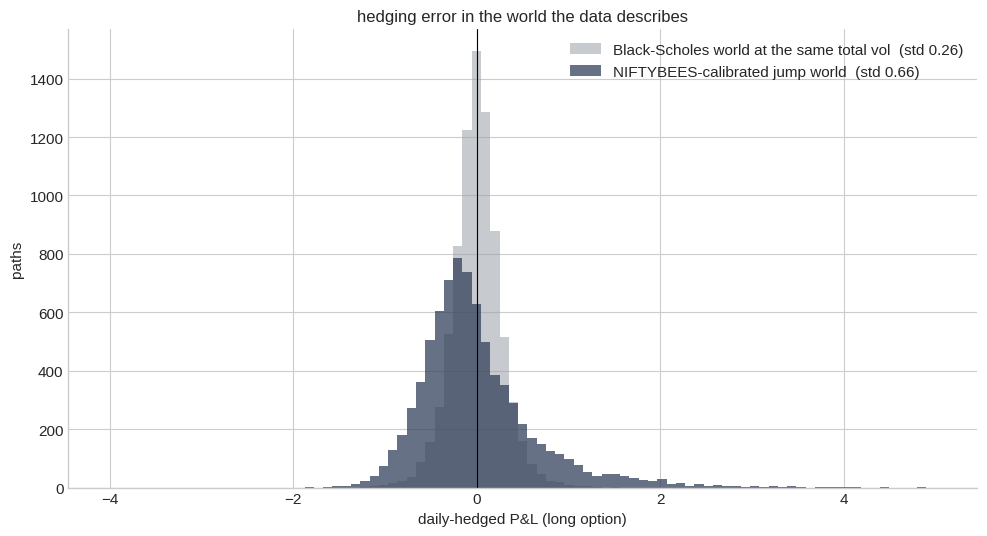

world                            mean     std    skew       P5      P95
Black-Scholes, same vol       -0.0004  0.2646   +0.10   -0.428   +0.426
NIFTYBEES-calibrated jumps    +0.0076  0.6642   +1.85   -0.804   +1.246

std ratio (calibrated world / BS world): 2.51x


In [13]:
# Hedge a Black-Scholes book in the NIFTYBEES-calibrated world
SIG_IMP_SPY = sig_total_hat  # the hedger prices the all-in realized variance correctly
S_spy_world = make_merton_paths(252, 8000, 21, R, sig_diff_hat, lam_hat, mu_j_hat, sig_j_hat)
S_bs_world = make_gbm_paths(252, 8000, seed=21, sigma=SIG_IMP_SPY)

pnl_spyw = hedge_pnl(S_spy_world, sigma_imp=SIG_IMP_SPY)
pnl_bsw = hedge_pnl(S_bs_world, sigma_imp=SIG_IMP_SPY)

fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.linspace(-4, 5, 90)
ax.hist(pnl_bsw, bins=bins, alpha=0.55, color=C_MUTED,
        label=f"Black-Scholes world at the same total vol  (std {pnl_bsw.std():.2f})")
ax.hist(pnl_spyw, bins=bins, alpha=0.75, color=C_MAIN,
        label=f"NIFTYBEES-calibrated jump world  (std {pnl_spyw.std():.2f})")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("daily-hedged P&L (long option)"); ax.set_ylabel("paths")
ax.set_title("hedging error in the world the data describes")
ax.legend()
plt.tight_layout(); plt.show()

print(f"{'world':28s} {'mean':>8s} {'std':>7s} {'skew':>7s} {'P5':>8s} {'P95':>8s}")
for name, p in [("Black-Scholes, same vol", pnl_bsw), ("NIFTYBEES-calibrated jumps", pnl_spyw)]:
    print(f"{name:28s} {p.mean():+8.4f} {p.std():7.4f} {skew(p):+7.2f} "
          f"{np.percentile(p, 5):+8.3f} {np.percentile(p, 95):+8.3f}")
print(f"\nstd ratio (calibrated world / BS world): {pnl_spyw.std() / pnl_bsw.std():.2f}x")

## 11. The Morning Risk Report

A risk committee reads the tail, not the mean. With losses reported as positive numbers,

$$\text{VaR}_{95} = -\,q_{5\%}(\text{P\&L}), \qquad
\text{CVaR}_{95} = -\,\mathbb{E}\big[\text{P\&L} \mid \text{P\&L} \le q_{5\%}\big],$$

value-at-risk is the loss threshold the worst 5% of outcomes at least reach, and CVaR (expected shortfall) is the average loss inside that tail. CVaR dominates VaR for reporting because VaR is blind beyond its own threshold, while CVaR is a coherent risk measure in the sense of Artzner, Delbaen, Eber and Heath (1999), and bank market-risk capital itself moved from VaR to expected shortfall under the FRTB framework.

The report below runs the same policy (band hedge, $h = 0.05$, 10 basis point costs) in three worlds calibrated to the same total variance: the Black-Scholes world the book was priced in, the stylized Merton world, and the Heston world. The pattern to read: in the world you priced, the mean P&L is approximately minus the friction bill and the tail is modest; in the worlds you did not price, the tail roughly doubles at essentially unchanged cost. Model risk is a tail phenomenon, not a cost phenomenon.


MORNING RISK REPORT   long one-year at-the-money call, band hedge h=0.05, costs 10 basis points
world                          mean     std   VaR95   CVaR95  E[cost]
Black-Scholes                -0.379   0.667   1.476    1.819    0.393
Merton jumps (stylized)      -0.645   3.405   3.461    3.805    0.324
Heston stochastic vol        -0.645   1.596   3.096    3.690    0.375
NIFTYBEES-calibrated jumps   -0.383   0.711   1.397    1.642    0.368

tail multiple vs the priced world: Merton 2.1x,  Heston 2.0x,  NIFTYBEES-calibrated 0.9x


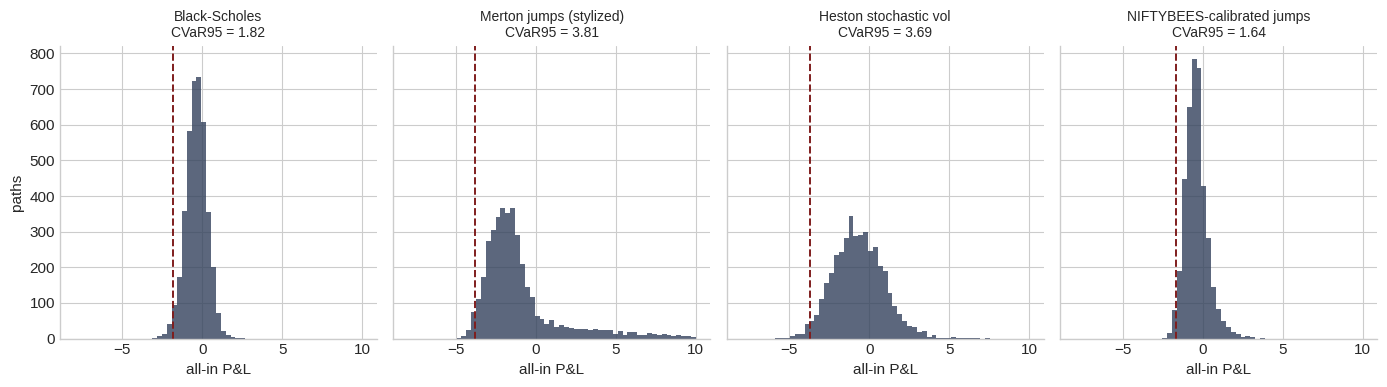

In [14]:
def var_cvar(pnl, level=0.95):
    """(VaR, CVaR) at the given level, losses as positive numbers."""
    q = np.quantile(pnl, 1.0 - level)
    return -q, -pnl[pnl <= q].mean()

H_BAND = 0.05
worlds = [
    ("Black-Scholes", make_gbm_paths(252, 4000, seed=42)),
    ("Merton jumps (stylized)", make_merton_paths(252, 4000, 42, R, SIG_DIFF, LAM_J, MU_J, SIG_J)),
    ("Heston stochastic vol", make_heston_paths(252, 4000, 42, R, V0H, KAPPA, THETA_H, XI, RHO)),
    ("NIFTYBEES-calibrated jumps", make_merton_paths(252, 4000, 42, R, sig_diff_hat, lam_hat, mu_j_hat, sig_j_hat)),
]

print(f"MORNING RISK REPORT   long one-year at-the-money call, band hedge h={H_BAND}, costs 10 basis points")
print(f"{'world':26s} {'mean':>8s} {'std':>7s} {'VaR95':>7s} {'CVaR95':>8s} {'E[cost]':>8s}")
results = []
for name, Sw in worlds:
    sig_use = SIG_IMP_SPY if "NIFTYBEES" in name else SIGMA
    repl, cost = band_hedge(Sw, sigma_imp=sig_use, h=H_BAND)
    net = repl - cost
    va, cv = var_cvar(net)
    results.append((name, net, cv))
    print(f"{name:26s} {net.mean():+8.3f} {net.std():7.3f} {va:7.3f} {cv:8.3f} {cost.mean():8.3f}")

cv_bs = results[0][2]
print(f"\ntail multiple vs the priced world: " + ",  ".join(
    f"{name.split(' ')[0]} {cv / cv_bs:.1f}x" for name, _, cv in results[1:]))

fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
bins = np.linspace(-8, 10, 60)
for ax, (name, net, cv) in zip(axes, results):
    ax.hist(net, bins=bins, color=C_MAIN, alpha=0.8)
    ax.axvline(-cv, color=C_ACCENT, lw=1.4, ls="--")
    ax.set_title(f"{name}\nCVaR95 = {cv:.2f}", fontsize=10)
    ax.set_xlabel("all-in P&L")
axes[0].set_ylabel("paths")
plt.tight_layout(); plt.show()

## 12. Summary and Conclusions

**The replication argument and its leftovers.** Delta hedging converts an option from a directional bet into a bet on how variance is delivered (Section 1). Discretely rebalanced, the leftover is mean-zero noise whose standard deviation falls like $1/\sqrt{N}$, and it is exactly the discretization error of quadratic variation seen through gamma (Section 5). Repricing attributes the P&L exactly into a non-negative convexity stream and a non-positive decay stream (Section 6).

**Frictions create an interior optimum.** Proportional costs grow like $\sqrt{N}$ against risk falling like $1/\sqrt{N}$, giving an optimal frequency $N^* = \lambda b / a$, in our calibration roughly one rebalance every three trading days rather than daily. Move-based band hedging dominates any clock: in our runs, 14-19% less replication risk at matched cost (Section 7). A Leland-style widened volatility prices the expected cost flow to within a few percent.

**Model risk is what the hedge cannot touch.** Under variance-matched jumps the error refuses to shrink with frequency (the jump floor), the distribution turns violently right-skewed for the long hedger, and a systematic drift appears because gamma is local (Section 8). Under stochastic volatility a second risk factor leaks through as unhedged vega (Section 9). Real NIFTYBEES.NS (Nifty 50 ETF) data calibrates to roughly three jumps per year ($\hat{\lambda} \approx 2.7$), each far smaller than the stylized crash ($\pm 3\%$ rather than $10\%$), and hedging a book in that calibrated world does *not* reproduce the fat-tail signature of the stylized worlds: CVaR$_{95}$ comes out at roughly $0.9\times$ the priced Black-Scholes book, against $\approx 2\times$ under the stylized Merton and Heston dynamics (Section 10) — evidence that jump risk is real but was overstated by the stylized calibration, at least over this sample window. Across all three worlds the desk report quantifies the principle a derivatives desk lives by: a hedge does not remove risk, it chooses which risks remain, and CVaR is the number that prices the remainder (Section 11).

**Drift never mattered.** The hedged P&L distribution is invariant to the real-world drift, measured directly in Section 9, which is the experimental content of risk-neutral pricing.


## 13. Extensions and Research Directions

Each direction below is an active research thread with a concrete first step that starts from code already in this notebook.

### 13.1 Deep hedging

Buehler, Gonon, Teichmann and Wood (2019) replace the model-derived delta with a neural network policy trained by minimizing a convex risk measure of terminal P&L over simulated paths, naturally accommodating transaction costs, market impact, and risk limits, and the framework is in industrial use on derivatives desks. This notebook is, almost verbatim, the training environment such a system needs: the simulators of Sections 8-10 generate the worlds, and the cost-aware engine of Section 7 scores the policy. **First step:** parameterize the hedge ratio as a small feedforward network of $(S, \tau, \Delta_{\text{held}})$ and train it against the band benchmark under the CVaR objective of Section 11.

### 13.2 No-transaction band networks

Imaki, Imajo, Ito, Minami and Nakagawa (2021) prove that the optimal deep-hedging policy under proportional costs inherits exactly the no-transaction band structure of Section 7.4, and build the band into the network architecture, achieving roughly $20\times$ faster training. Follow-up work on structural priors for these networks is appearing as recently as 2026. The band hedger implemented here is the zero-parameter ancestor of that architecture. **First step:** replace our constant band width $h$ with a parameterized function $h(S, \tau)$ and fit it on the cost-risk frontier.

### 13.3 Reinforcement learning for hedging

Kolm and Ritter (2019) formulate discrete hedging as a reinforcement learning problem and show the agent recovers the optimal cost-risk tradeoff without being told the cost function's form, useful precisely where costs are nonlinear or unknown. Our Section 7 engine provides the environment and the exact-cost baseline an RL agent must beat. **First step:** wrap the cost-aware hedge loop as a gym-style environment with state $(S, \tau, \Delta_{\text{held}})$ and mean-variance reward.

### 13.4 Minimum-variance deltas from data

Hull and White (2017) show empirically, on S&P 500 options, that the variance-minimizing hedge ratio differs systematically from the Black-Scholes delta because spot and implied volatility move together (the leverage effect), and estimate the correction directly from data. Our Heston world generates exactly this effect by construction ($\rho < 0$). **First step:** regress the hedged P&L of Section 9 on $\mathcal{V}/(S\sqrt{T})$-style correction terms and verify the fitted minimum-variance delta shrinks the error floor.

### 13.5 Rough volatility

Gatheral, Jaisson and Rosenbaum (2018) document that realized volatility behaves like fractional Brownian motion with Hurst exponent near $0.1$, far rougher than Heston's diffusion, with material consequences for the term structure of hedging error. **First step:** swap the CIR variance of Section 9 for a rough kernel simulation and re-measure the error floor and its dependence on rebalancing frequency.

### 13.6 Trading the variance bet directly: variance swaps

The identity of Section 4 says a hedged option is a variance bet distorted by a gamma weight. Demeterfi, Derman, Kamal and Zou (1999) show the distortion can be removed: a static portfolio of options with weights $\propto 1/K^2$ replicates the log contract, whose delta-hedged P&L pays realized variance with **constant** dollar gamma. Strikingly, their replication argument fails exactly where our Section 8 does, when the price jumps. **First step:** build the strike-strip replication numerically and re-run the Section 8 experiment on the log contract to see the jump bias reappear in instrument form.


## 14. References

1. **Black, F. and Scholes, M.** (1973). "The Pricing of Options and Corporate Liabilities." *Journal of Political Economy*, 81(3), 637-654.
2. **Merton, R.C.** (1973). "Theory of Rational Option Pricing." *Bell Journal of Economics and Management Science*, 4(1), 141-183.
3. **Merton, R.C.** (1976). "Option pricing when underlying stock returns are discontinuous." *Journal of Financial Economics*, 3(1-2), 125-144. - The jump-diffusion model of Section 8.
4. **Boyle, P.P. and Emanuel, D.** (1980). "Discretely adjusted option hedges." *Journal of Financial Economics*, 8(3), 259-282. - The chi-squared local hedging error of Section 5.
5. **Leland, H.E.** (1985). "Option Pricing and Replication with Transactions Costs." *Journal of Finance*, 40(5), 1283-1301. - The widened-volatility idea verified in Section 7.3; see Kabanov and Safarian (1997) for the correction to its limit theorem.
6. **Heston, S.L.** (1993). "A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options." *Review of Financial Studies*, 6(2), 327-343.
7. **Whalley, A.E. and Wilmott, P.** (1997). "An Asymptotic Analysis of an Optimal Hedging Model for Option Pricing with Transaction Costs." *Mathematical Finance*, 7(3), 307-324. - The cube-root band law of Section 7.4.
8. **Artzner, P., Delbaen, F., Eber, J.-M. and Heath, D.** (1999). "Coherent Measures of Risk." *Mathematical Finance*, 9(3), 203-228. - Why CVaR, not VaR, in Section 11.
9. **Demeterfi, K., Derman, E., Kamal, M. and Zou, J.** (1999). "A Guide to Volatility and Variance Swaps." *Journal of Derivatives*, 6(4), 9-32.
10. **Barndorff-Nielsen, O.E. and Shephard, N.** (2004). "Power and Bipower Variation with Stochastic Volatility and Jumps." *Journal of Financial Econometrics*, 2(1), 1-37. - The rigorous jump-separation alternative to Section 10's threshold method.
11. **Lord, R., Koekkoek, R. and van Dijk, D.** (2010). "A comparison of biased simulation schemes for stochastic volatility models." *Quantitative Finance*, 10(2), 177-194. - The full truncation scheme of Section 9.
12. **Hull, J. and White, A.** (2017). "Optimal delta hedging for options." *Journal of Banking & Finance*, 82, 180-190.
13. **Gatheral, J., Jaisson, T. and Rosenbaum, M.** (2018). "Volatility is rough." *Quantitative Finance*, 18(6), 933-949.
14. **Buehler, H., Gonon, L., Teichmann, J. and Wood, B.** (2019). "Deep hedging." *Quantitative Finance*, 19(8), 1271-1291.
15. **Kolm, P.N. and Ritter, G.** (2019). "Dynamic Replication and Hedging: A Reinforcement Learning Approach." *Journal of Financial Data Science*, 1(1), 159-171.
16. **Imaki, S., Imajo, K., Ito, K., Minami, K. and Nakagawa, K.** (2021). "No-Transaction Band Network: A Neural Network Architecture for Efficient Deep Hedging." arXiv:2103.01775.

---

